# Final Assignment

## Elsie Chilwane (CHLMOT003)

### SEA4001W 
### P4 - Final Assignment: Putting it all together
### Marcello Vichi 

In [325]:
# Import the necessary packages:

import xarray as xr
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo

In [326]:
# Get necessary data

chloro_data = xr.open_dataset('C:/Users/4203750/Documents/2026 Oceanography Honours/Week 4-8_Introduction_To_Data_Science/Exercises_And_Assignments/Data/ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc')
bathy_data = xr.open_dataset('C:/Users/4203750/Documents/2026 Oceanography Honours/Week 4-8_Introduction_To_Data_Science/Exercises_And_Assignments/Data/GMRTv4_4_1_20260326topo.grd')

In [327]:
# Explore the chlorophyll data

# N= 38
# S= 35
# W = -124
# E = -121

#print(chloro_data['chlor_a'])

#Coordinates:
  #* time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  #* lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  #* lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0

start_date = '1997-12-01'
end_date = '1998-08-01'

#chloro_data.info()

In [328]:
# Exploring Bathymetry data

#print(bathy_data.lat.values[:5])
#print(bathy_data.lon.values[:5])
#print(bathy_data)

# <xarray.Dataset> Size: 19MB
#Dimensions:   (lat: 1700, lon: 1367)
#Coordinates:
#  * lat       (lat) float64 14kB 35.0 35.0 35.0 35.0 ... 38.0 38.0 38.0 38.0
#  * lon       (lon) float64 11kB -124.0 -124.0 -124.0 ... -121.0 -121.0 -121.0
#Data variables:
#    altitude  (lat, lon) float64 19MB nan nan nan nan ... 42.0 43.0 44.0 44.0
#Attributes:
#    title:        GMRT Grid
#    history:      Projection: Cylindrical Equidistant\nExtracted from the Glo...
#    Conventions:  COARDS,CF-1.6
#    GMT_version:  4.5.7

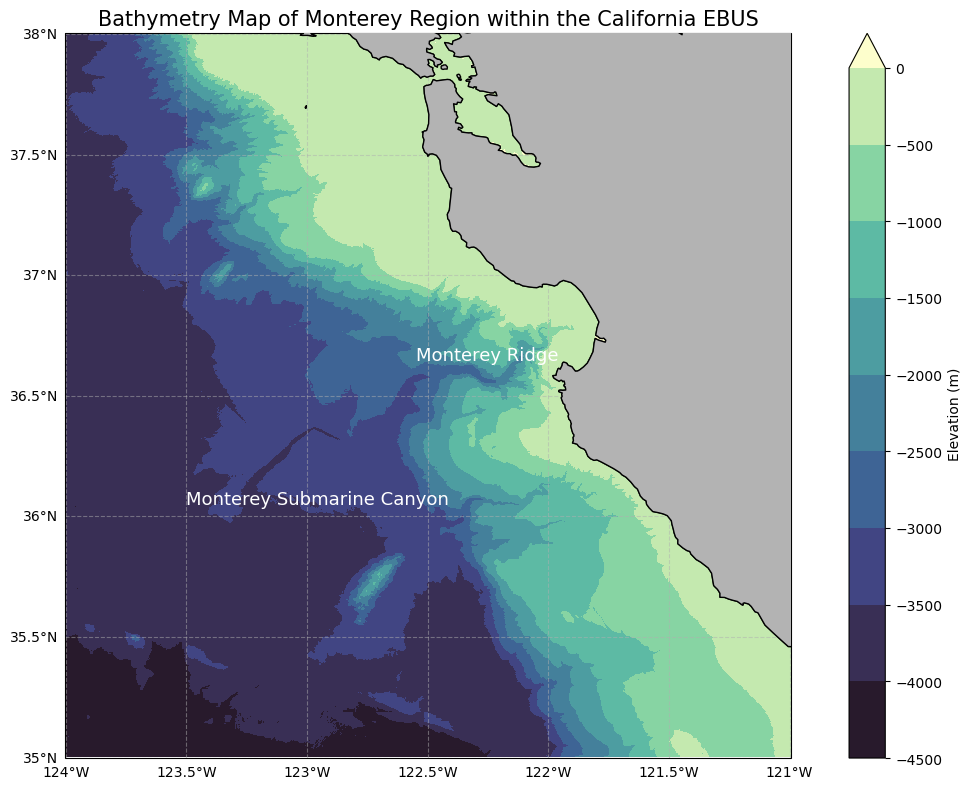

In [329]:
#                                                   Bathymetry Plot


extent = [-124, -121, 35.5, 38] 

fig = plt.figure(figsize=(12, 8))

# projection
ax = plt.axes( projection=ccrs.PlateCarree())

bathy_data.altitude.plot( ax=ax,transform=ccrs.PlateCarree(), levels=np.arange(-4500, 1, 500), cmap='cmo.deep_r', cbar_kwargs={'label': 'Elevation (m)'})

# Add Map features
ax.add_feature( cfeature.LAND, facecolor='0.7', edgecolor='black',  zorder=15) # 0.7 suggestion
ax.coastlines( resolution='10m', linewidth=0.8)
gl = ax.gridlines( draw_labels=True, linestyle='--', alpha=0.5)

# Plot latitudes and longitudes
gl.bottom_labels = True
gl.right_labels = False
gl.top_labels = False

# Add aesthetic text
ax.text(-122.55, 36.65, 'Monterey Ridge', color='white', transform=ccrs.PlateCarree(), fontsize = 13)
ax.text(-123.5, 36.05, 'Monterey Submarine Canyon', color='white', transform=ccrs.PlateCarree(), fontsize = 13)


#Set the title
ax.set_title('Bathymetry Map of Monterey Region within the California EBUS', fontsize=15)

plt.tight_layout()
plt.savefig('Bathymetry Map of Monterey Region within the California EBUS.png', dpi = 300)
plt.show()


C:\Users\4203750\AppData\Local\Temp\ipykernel_3444\1581888157.py:32: UserWarning: Adding colorbar to a different Figure <Figure size 1200x800 with 2 Axes> than <Figure size 1200x800 with 2 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax, orientation='vertical')


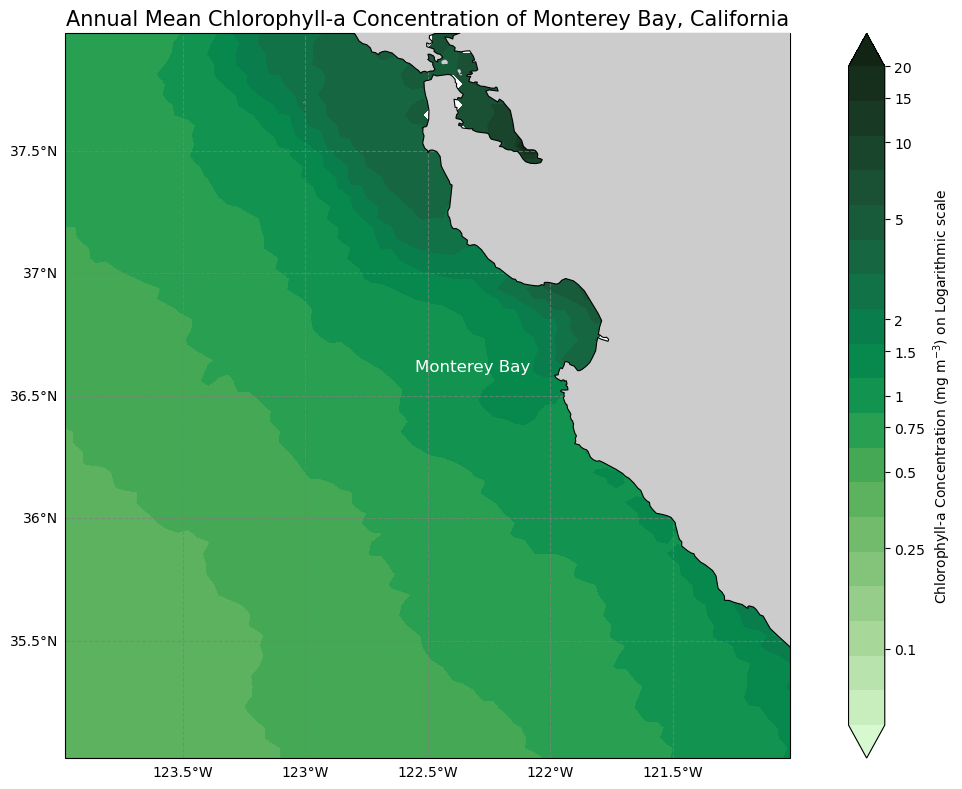

In [334]:
#                                                 Chlorophyll Map 


monte_reg = chloro_data.sel( lon=slice( -124, -121), lat=slice(38, 35))

fig = plt.figure(figsize=(12, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

# Extract annual mean
annual_mean = monte_reg['chlor_a'].mean(dim='time')
#print(annual mean)

# Work Logarithmic Scale
vmin = 0.05
vmax = 20
levels = np.logspace(np.log10(vmin), np.log10(vmax), 20) #assistance

annual_mean_chloro = annual_mean.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),cmap='cmo.algae', levels= levels, norm= colors.LogNorm(vmin=vmin, vmax=vmax),extend='both',add_colorbar=False)

#Add Map Features
ax.add_feature(cfeature.LAND, facecolor='0.8', zorder=5)
ax.coastlines(resolution='10m', linewidth=0.8, zorder=11)
gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.7, linestyle='--')
gl.bottom_labels = True
gl.right_labels = False
gl.top_labels = False

ax.text(-122.55, 36.60, 'Monterey Bay', color='white', transform=ccrs.PlateCarree(), fontsize = 12)

# Colorbar aesthetic
cbar = plt.colorbar(im, ax=ax, orientation='vertical')
cbar.set_label('Chlorophyll-a Concentration (mg/ m$^{-3}$) on Logarithmic scale')

# Fixing the colourbar to get logarthmic scale properly
ticks = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 5, 10, 15, 20]
cbar.set_ticks(ticks)
cbar.set_ticklabels([str(t) for t in ticks]) #Assistance for loop ensures ticks align with tick defined values

plt.title('Annual Mean Chlorophyll-a Concentration of Monterey Bay, California', fontsize=15)

plt.tight_layout()
plt.savefig('Annual Mean Chlorophyll-a Concentration of Monterey Bay Region .png', dpi = 300)
plt.show()

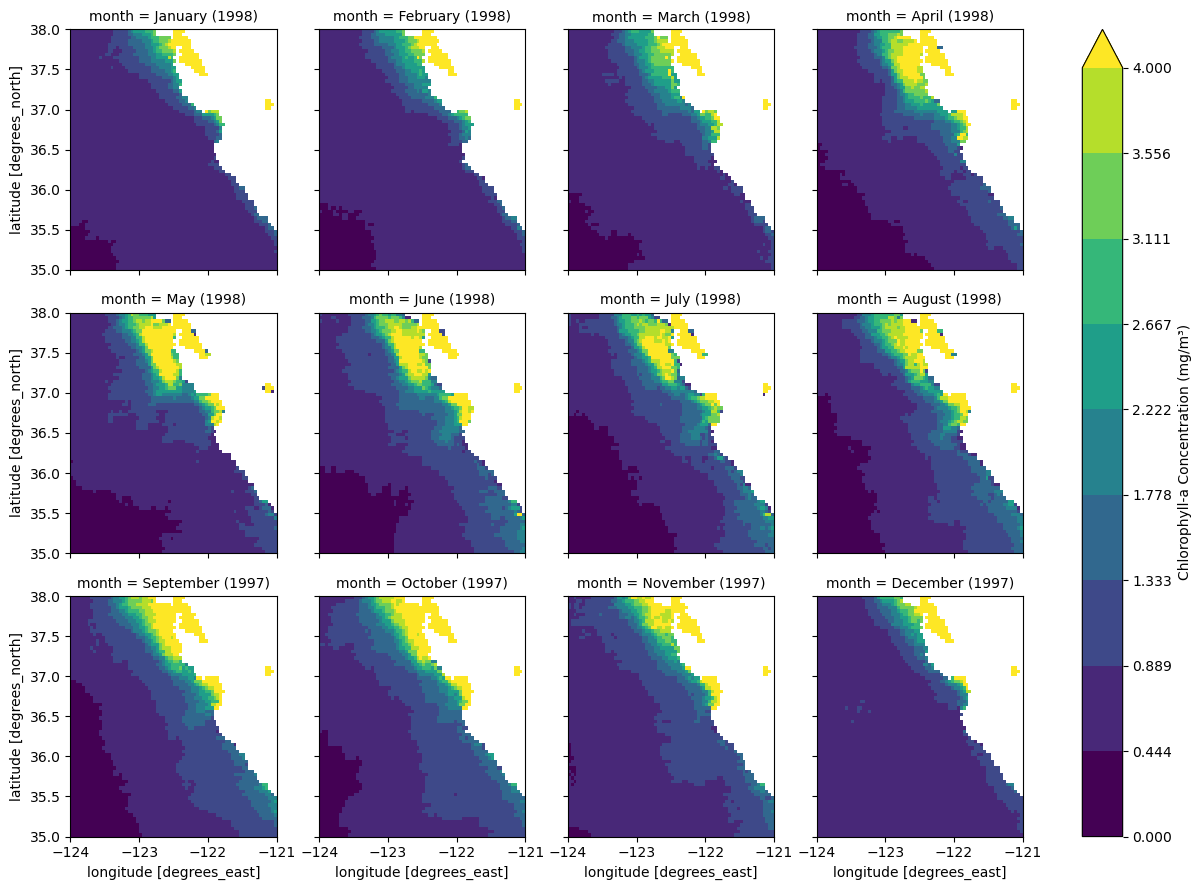

In [335]:
#                                                      12 Panel Plot 


monte_reg = chloro_data.sel(lon=slice(-124, -121), lat=slice(38, 35))

#print(chloro_data['time.month'].values) #[9,10,11,12,1,2,3,4,5,6,7,8]

# 2. Apply the groupby method
twelve_panel = monte_reg.groupby('time.month').mean()
# print(twelve_panel) #[1,2,3,4,5,6,7,8,9,10,11,12]

months_of_the_year = ['January (1998)','February (1998)','March (1998)','April (1998)','May (1998)','June (1998)','July (1998)','August (1998)', 'September (1997)','October (1997)','November (1997)','December (1997)']
#Apply the months coordinate to the defined months for plot
twelve_panel.coords['month'] = months_of_the_year

levels = np.linspace( 0, 4, 10)

twelve_panel.chlor_a.plot(col='month',col_wrap=4,cmap='viridis', levels = levels, cbar_kwargs={'label': 'Chlorophyll-a Concentration (mg/m³)'})


plt.savefig('12 panel.png', dpi = 300)
plt.show()

[37.97916667 37.9375     37.89583333 37.85416667 37.8125    ]
[-123.97916667 -123.9375     -123.89583333 -123.85416667 -123.8125    ]


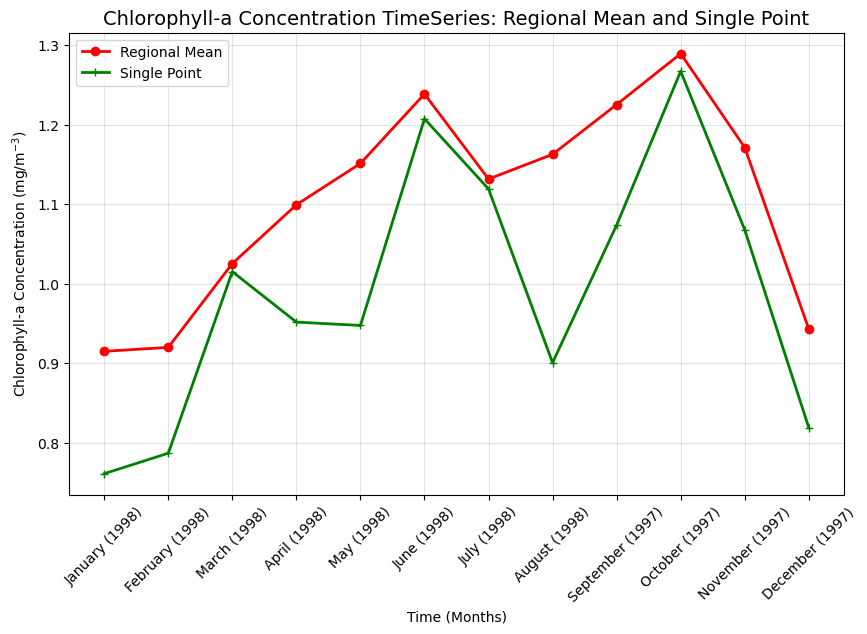

In [342]:
#                                             TimeSeries Plot

fig, ax  = plt.subplots(figsize=(10, 6))

monte_reg = chloro_data.sel(lon=slice(-124, -121), lat=slice(38, 35))

# Collapse into a timeseries

monte_reg_mean = monte_reg.chlor_a.mean(dim=['lat', 'lon'])

monte_reg_s_mean = monte_reg_mean.groupby('time.month').mean()

ax.plot(months, monte_reg_s_mean, color='red', marker='o', linewidth=2, label='Regional Mean')


#Finding a high chlorophyll point
annual_mean = monte_reg['chlor_a'].mean(dim='time') #print(annual_mean)
#print(monte_reg.lat.values[:5])
#print(monte_reg.lon.values[:5])

# Monterey region centralised point 
#lat_centre = (38 + 35) / 2 = 36.7
#lon_centre = (-124 + -121) / 2 = 122.5

single_point = chloro_data.chlor_a.sel(lon=-122.5, lat=36.7, method='nearest')

single_point_s_mean = single_point.groupby('time.month').mean()

ax.plot(months, single_point_s_mean, color='green', marker='+', linewidth=2, label='Single Point')

months = ['January (1998)','February (1998)','March (1998)','April (1998)','May (1998)','June (1998)','July (1998)','August (1998)','September (1997)','October (1997)','November (1997)','December (1997)']

ax.set_xticks(range(12))
ax.set_xticklabels(months, rotation = 45)

ax.set_title('Chlorophyll-a Concentration TimeSeries: Regional Mean and Single Point', fontsize=14)
ax.set_ylabel('Chlorophyll-a Concentration (mg/m$^{-3}$)')
ax.set_xlabel('Time (Months)')
plt.legend(loc = 'upper left') 
plt.grid(alpha = 0.35)

plt.savefig('Chlorophyll_Comparision', dpi = 300)
plt.show()
